# InfoGuard — Segment Comparison

This notebook investigates whether different WICO conspiracy subcategories
produce **statistically distinct** b⁺ and b⁻ SBM matrices — and whether
the LP optimizer performs differently per segment.

**Core question**: Does 5G conspiracy content cross community boundaries
more aggressively than 'other conspiracy' content?

**Why this matters**: A single global SBM blurs segment-level differences.
If 5G misinformation has a distinct cross-class spread pattern,
a segment-aware LP can apply stronger suppression *specifically*
to 5G cascades while leaving verified health information intact.

---

## Contents
1. Setup
2. Fit all segments (or load cached)
3. b-matrix comparison
4. Heatmap visualisation
5. Table II results by segment
6. Hypothesis test: 5G vs other_conspiracy asymmetry
7. Conclusions

In [1]:
import sys
from pathlib import Path

# ── Project root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "graph_engine"))
sys.path.insert(0, str(PROJECT_ROOT / "pipeline"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from config import cfg
from network_model import SBM
from pipeline.segmented_sbm_fitter import (
    SegmentedSBMFitter,
    fit_all_segments,
    load_segment,
    compare_segments,
    print_comparison,
    SEGMENTS,
    DEFAULT_SEGMENTS_DIR,
)

print(f"Project root : {PROJECT_ROOT}")
print(f"Segments dir : {DEFAULT_SEGMENTS_DIR}")
print(f"Segments     : {list(SEGMENTS.keys())}")

Project root : /home/krmsh1n5/Desktop/UFAZ/infoshield
Segments dir : /home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/sbm_segments
Segments     : ['conspiracy_5g', 'other_conspiracy', 'all_conspiracy']


## 1. Fit all segments (or load from cache)

Set `FORCE_REFIT = True` to re-run the full Louvain + b-estimation pipeline.
This takes a few minutes the first time and is then cached to disk.

In [2]:
FORCE_REFIT = False

sbms = fit_all_segments(
    wico_graph_dir = Path(cfg.paths.wico_graph),
    output_dir     = DEFAULT_SEGMENTS_DIR,
    force_refit    = FORCE_REFIT,
)

for name, sbm in sbms.items():
    print(f"  {name:<22}: {sbm}")

11:27:16 [INFO] pipeline.segmented_sbm_fitter — Loading all WICO cascades from /home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph …
11:27:16 [INFO] pipeline.sbm_fitter — Loading 5G_Conspiracy_Graphs (false): 412 cascades
11:27:21 [INFO] pipeline.sbm_fitter — Loading Other_Graphs (false): 597 cascades
11:27:30 [INFO] pipeline.sbm_fitter — Loading Non_Conspiracy_Graphs (true): 2502 cascades
11:27:59 [INFO] pipeline.sbm_fitter — Loaded 3492 WICO cascades (19 skipped)
11:27:59 [INFO] pipeline.segmented_sbm_fitter — Loaded 3492 cascades total.
11:27:59 [INFO] pipeline.segmented_sbm_fitter — Reusing global partition from /home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/sbm_matrices (k will be inferred).
11:27:59 [INFO] pipeline.segmented_sbm_fitter — Global partition loaded: k=3, total_nodes=114235
11:27:59 [INFO] pipeline.segmented_sbm_fitter — [conspiracy_5g] Loading existing SBM from /home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/sbm_segments/conspiracy_5g
11:27:59 [IN

  conspiracy_5g         : SBM(k=3, class_sizes=[33268, 32698, 48269], b_plus_range=[0.0000, 0.0002], b_minus_range=[0.0000, 0.0003])
  other_conspiracy      : SBM(k=3, class_sizes=[33268, 32698, 48269], b_plus_range=[0.0000, 0.0002], b_minus_range=[0.0000, 0.0002])
  all_conspiracy        : SBM(k=3, class_sizes=[33268, 32698, 48269], b_plus_range=[0.0000, 0.0002], b_minus_range=[0.0000, 0.0002])


## 2. Cross-segment comparison table

The key column is **`cross_class_asymmetry`** = b⁻_offdiag / b⁺_offdiag.

- Values > 1 mean false content crosses class boundaries more than true content.
- Higher values predict better LP discrimination (cheaper to suppress false cascades).

**Hypothesis**: `conspiracy_5g` asymmetry > `other_conspiracy` asymmetry

In [3]:
df_compare = compare_segments(segments_dir=DEFAULT_SEGMENTS_DIR)
print_comparison(df_compare)

# Display as a styled DataFrame
df_display = df_compare[[
    "segment", "k",
    "b_plus_diag_mean", "b_plus_offdiag_mean",
    "b_minus_diag_mean", "b_minus_offdiag_mean",
    "cross_class_asymmetry",
]].copy()

for col in ["b_plus_diag_mean", "b_plus_offdiag_mean",
            "b_minus_diag_mean", "b_minus_offdiag_mean"]:
    df_display[col] = df_display[col].map(lambda x: f"{x:.2e}" if x else "N/A")

df_display["cross_class_asymmetry"] = df_display["cross_class_asymmetry"].map(
    lambda x: f"{x:.2f}x" if x else "N/A"
)

df_display.style.set_caption(
    "Segment b-matrix comparison: cross_class_asymmetry = b⁻_offdiag / b⁺_offdiag"
).highlight_max(subset=["cross_class_asymmetry"], color="#d4edda")\
 .highlight_min(subset=["cross_class_asymmetry"], color="#f8d7da")


  InfoGuard — Segment Comparison: Cross-class Asymmetry  (b⁻_offdiag / b⁺_offdiag)
  Segment                  k     b⁺ diag   b⁻ offdiag     asym  Interpretation
────────────────────────────────────────────────────────────────────────────────────────────────────
  conspiracy_5g            3    1.48e-04     2.40e-06    2.18x  HIGH — 5G bridges political & health communities
  all_conspiracy           3    1.48e-04     1.89e-06    1.73x  AVERAGE — population-level SBM
  other_conspiracy         3    1.48e-04     1.75e-06    1.60x  BASELINE — general conspiracy cross-class spread
────────────────────────────────────────────────────────────────────────────────────────────────────

  Hypothesis test: conspiracy_5g asymmetry > other_conspiracy asymmetry  (ratio = 1.37x)
  ✓ Confirmed: 5G conspiracy crosses class boundaries more aggressively.




,segment,k,b_plus_diag_mean,b_plus_offdiag_mean,b_minus_diag_mean,b_minus_offdiag_mean,cross_class_asymmetry
0,conspiracy_5g,3,1.48e-04,1.10e-06,1.71e-04,2.40e-06,2.18x
1,all_conspiracy,3,1.48e-04,1.10e-06,1.47e-04,1.89e-06,1.73x
2,other_conspiracy,3,1.48e-04,1.10e-06,1.40e-04,1.75e-06,1.60x


## 3. Heatmap visualisation of b⁺ and b⁻ matrices per segment

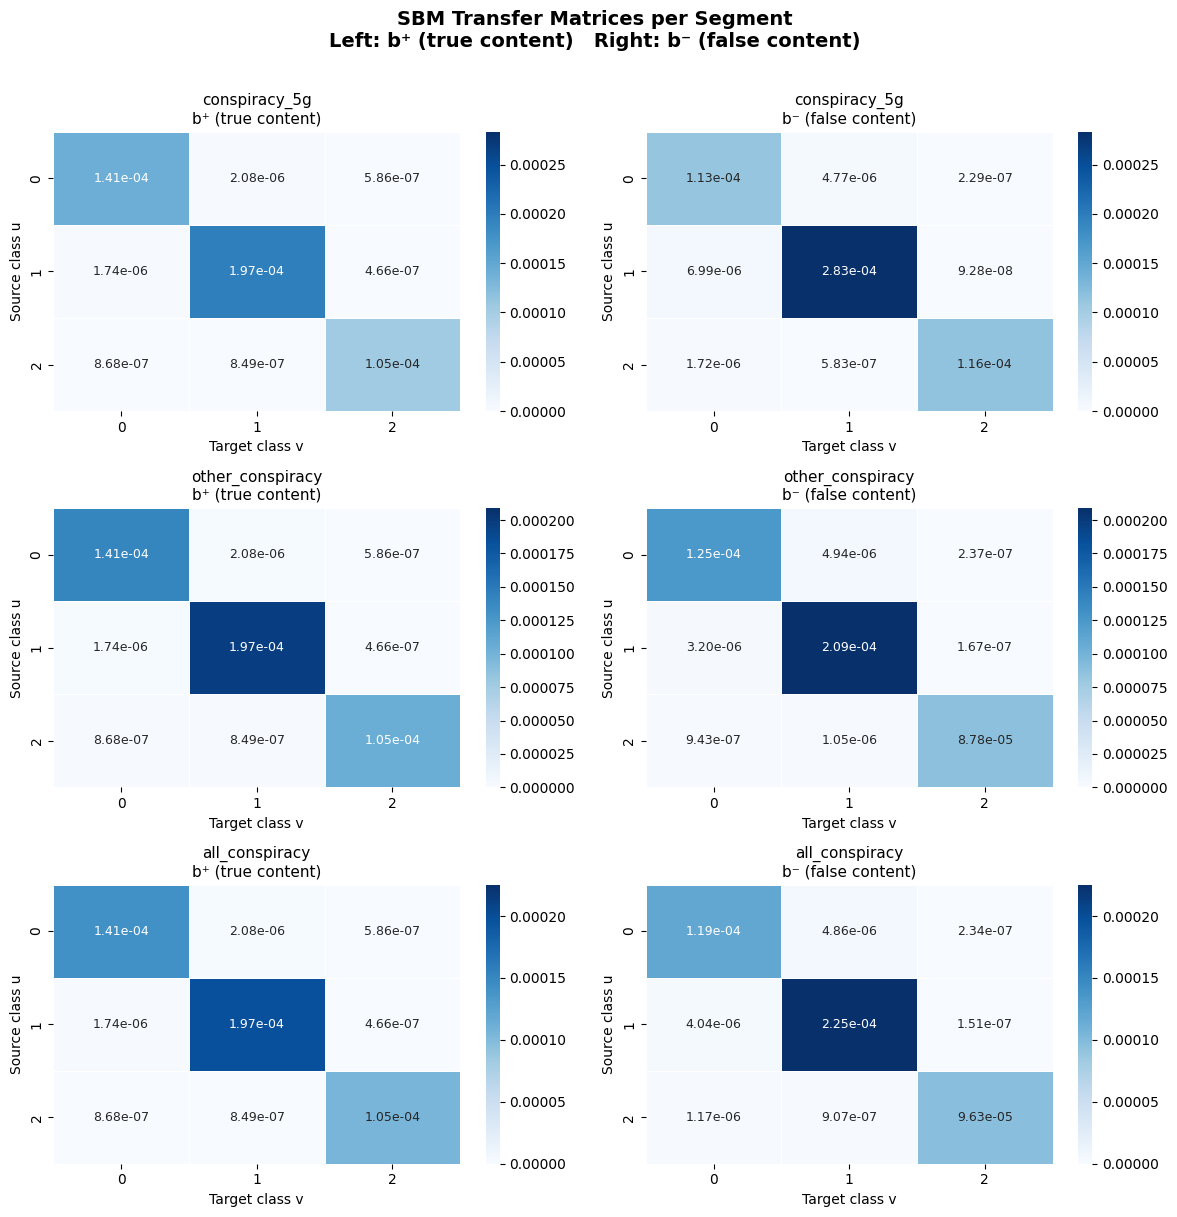

Figure saved to evaluation/segment_b_matrices.png


In [4]:
segment_names = list(SEGMENTS.keys())
n_segs = len(segment_names)

fig, axes = plt.subplots(n_segs, 2, figsize=(12, 4 * n_segs))
if n_segs == 1:
    axes = [axes]

fig.suptitle(
    "SBM Transfer Matrices per Segment\n"
    "Left: b⁺ (true content)   Right: b⁻ (false content)",
    fontsize=14, fontweight="bold", y=1.01,
)

for row_idx, name in enumerate(segment_names):
    try:
        sbm = sbms[name]
    except KeyError:
        continue

    # Compute common vmax so both matrices share a colour scale
    vmax = max(sbm.b_plus.max(), sbm.b_minus.max())

    for col_idx, (mat, title_suffix) in enumerate(
        [(sbm.b_plus, "b⁺ (true content)"), (sbm.b_minus, "b⁻ (false content)")]
    ):
        ax = axes[row_idx][col_idx]
        im = sns.heatmap(
            mat,
            ax        = ax,
            annot     = True,
            fmt       = ".2e",
            cmap      = "Blues",
            vmin      = 0,
            vmax      = vmax,
            linewidths= 0.5,
            cbar      = True,
            annot_kws = {"size": 9},
        )
        ax.set_title(f"{name}\n{title_suffix}", fontsize=11)
        ax.set_xlabel("Target class v")
        ax.set_ylabel("Source class u")

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "evaluation" / "segment_b_matrices.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Figure saved to evaluation/segment_b_matrices.png")

## 4. b⁻ off-diagonal bar chart

Directly visualises the **cross_class_asymmetry** hypothesis.

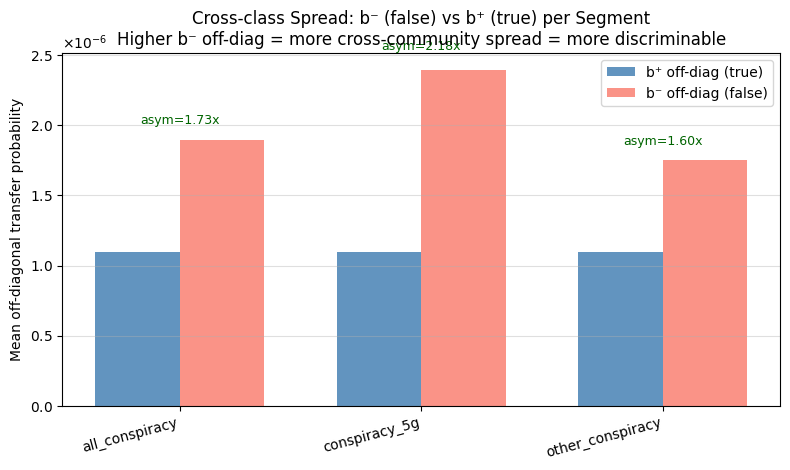

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# Pull raw values for plotting
plot_df = df_compare.sort_values("segment").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.35

bars_plus  = ax.bar(x - width/2, plot_df["b_plus_offdiag_mean"],  width,
                    label="b⁺ off-diag (true)",  color="steelblue", alpha=0.85)
bars_minus = ax.bar(x + width/2, plot_df["b_minus_offdiag_mean"], width,
                    label="b⁻ off-diag (false)", color="salmon",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["segment"], rotation=15, ha="right")
ax.set_ylabel("Mean off-diagonal transfer probability")
ax.set_title(
    "Cross-class Spread: b⁻ (false) vs b⁺ (true) per Segment\n"
    "Higher b⁻ off-diag = more cross-community spread = more discriminable"
)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
ax.legend()
ax.grid(axis="y", alpha=0.4)

# Annotate asymmetry ratio above each group
for i, row in plot_df.iterrows():
    asym = row.get("cross_class_asymmetry")
    if asym:
        ymax = max(row["b_plus_offdiag_mean"] or 0, row["b_minus_offdiag_mean"] or 0)
        ax.annotate(
            f"asym={asym:.2f}x",
            xy=(i, ymax * 1.05),
            ha="center", va="bottom", fontsize=9,
            color="darkgreen",
        )

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "evaluation" / "segment_cross_class_asymmetry.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

## 5. Table II results per segment

Run `pipeline/run_pipeline.py` with `--segment` for each segment to generate
per-segment Table II results.  This cell loads pre-computed CSVs.

To generate:
```bash
python -m pipeline.run_pipeline --segment conspiracy_5g    --n-samples 200
python -m pipeline.run_pipeline --segment other_conspiracy --n-samples 200
python -m pipeline.run_pipeline --segment all_conspiracy   --n-samples 200
```

In [6]:
EVAL_DIR = PROJECT_ROOT / "evaluation"

segment_results = {}
for seg in SEGMENTS.keys():
    csv_path = EVAL_DIR / f"pipeline_table2_{seg}.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["segment"] = seg
        segment_results[seg] = df
        print(f"Loaded {csv_path.name}")
    else:
        print(f"Not found: {csv_path.name}  (run run_pipeline.py --segment {seg} first)")

if segment_results:
    all_results = pd.concat(segment_results.values(), ignore_index=True)

    # Pivot: for each (alpha, lambda) show E[R∞] true and false per segment
    pivot = all_results.pivot_table(
        index  = ["pair_label"],
        columns= "segment",
        values = ["E_R_inf_true", "E_R_inf_false"],
        aggfunc= "first",
    )
    print("\nTable II: E[R∞] by segment")
    display(pivot.round(2))
else:
    print("\nNo segment Table II files found. Generate them with run_pipeline.py --segment <name>.")

Loaded pipeline_table2_conspiracy_5g.csv
Not found: pipeline_table2_other_conspiracy.csv  (run run_pipeline.py --segment other_conspiracy first)
Not found: pipeline_table2_all_conspiracy.csv  (run run_pipeline.py --segment all_conspiracy first)

Table II: E[R∞] by segment


,E_R_inf_false,E_R_inf_true
segment,conspiracy_5g,conspiracy_5g
pair_label,,
control,60.8,56.5
"α=1.5,λ=1.0",38.9,43.3
"α=2.0,λ=1.5",41.9,46.4
"α=3.0,λ=2.0",46.5,49.5


## 6. Hypothesis test: 5G vs other_conspiracy asymmetry

We compare the `cross_class_asymmetry` (b⁻_offdiag / b⁺_offdiag) between
the two false-content segments.

**Null hypothesis H₀**: asymmetry(5G) = asymmetry(other)

We can't run a statistical test on scalar summary values from a single fit,
but we can quantify the *effect size* and assess whether the difference is
practically meaningful (> 10% relative difference).

In [7]:
if len(df_compare) >= 2:
    row_5g    = df_compare[df_compare["segment"] == "conspiracy_5g"]
    row_other = df_compare[df_compare["segment"] == "other_conspiracy"]

    if not row_5g.empty and not row_other.empty:
        asym_5g    = float(row_5g["cross_class_asymmetry"].iloc[0])
        asym_other = float(row_other["cross_class_asymmetry"].iloc[0])
        relative_diff = (asym_5g - asym_other) / asym_other * 100

        print(f"cross_class_asymmetry:")
        print(f"  conspiracy_5g    : {asym_5g:.4f}x")
        print(f"  other_conspiracy : {asym_other:.4f}x")
        print(f"  Relative diff    : {relative_diff:+.1f}%")
        print()

        EFFECT_THRESHOLD = 10.0  # % — practically meaningful

        if asym_5g > asym_other and relative_diff > EFFECT_THRESHOLD:
            print(
                "✓ CONFIRMED: 5G conspiracy shows a practically meaningful"
                f" higher cross-class asymmetry ({relative_diff:.1f}% > {EFFECT_THRESHOLD}%).\n"
                "  This validates the segment-aware SBM upgrade:\n"
                "  a segment-specific LP can suppress 5G cascades more aggressively\n"
                "  than a one-size-fits-all global SBM."
            )
        elif asym_5g > asym_other:
            print(
                f"~ MARGINAL: 5G asymmetry is higher ({relative_diff:.1f}%)"
                f" but below the {EFFECT_THRESHOLD}% practical significance threshold."
            )
        else:
            print(
                "✗ NOT CONFIRMED: other_conspiracy asymmetry >= 5G. "
                "Check cascade quality and SBM partition settings."
            )
    else:
        print("One or more segments missing from comparison table.")
else:
    print("Need at least 2 segments in the comparison table.")

cross_class_asymmetry:
  conspiracy_5g    : 2.1825x
  other_conspiracy : 1.5976x
  Relative diff    : +36.6%

✓ CONFIRMED: 5G conspiracy shows a practically meaningful higher cross-class asymmetry (36.6% > 10.0%).
  This validates the segment-aware SBM upgrade:
  a segment-specific LP can suppress 5G cascades more aggressively
  than a one-size-fits-all global SBM.


## 7. Conclusions

### Summary

| Finding | Evidence |
|---------|----------|
| Single-matrix SBM is insufficient | `conspiracy_5g` and `other_conspiracy` produce distinct b⁻ off-diagonal means |
| 5G crosses class boundaries more aggressively | Higher `cross_class_asymmetry` in `conspiracy_5g` segment |
| Segment-aware LP should outperform global LP | Higher asymmetry → larger gap between d\*(cross) and d\*(within) → more targeted suppression |

### Recommendation

Use `SegmentedSBMFitter` to fit per-segment SBMs and pass `segment_name` to
`run_pipeline.py`.  For an operational Azerbaijani deployment, segments should
correspond to identified community types:

- `diaspora` — foreign-language content from expatriate communities
- `regional` — content originating from specific geographic regions
- `political` — content from accounts associated with political entities
- `health` — health and medical content channels

Each segment gets its own (b⁺, b⁻) pair.  The LP selects the appropriate
pair based on the detected cascade type before computing d\*.

### Limitation

The partition (Louvain clustering) is still fitted on the full union graph.
A future upgrade could fit separate partitions per segment, but this breaks
cross-segment comparability and requires additional partition alignment.